En este trabajo se estudia el problema de contorno dado por:
		$$\frac{1}{\alpha} \frac{\partial T(x,t)}{\partial t}=\frac{\partial^2 T(x,t)}{\partial x^2}-\sigma^2 \left((T(x,t)\right) T(x,t)+f(x) \ , \ 0<x<L \ , \ 0<t<t_{max}$$
		$$\frac{\partial T(0,t)}{\partial x}=\beta T(0)-\gamma $$
		$$T(L,t)=\delta \ , \ 0<t<t_{max} $$
		$$f(x)=F_0 e^{-\mu x} \ , \ 0<t<t_{max}$$
La parte espacial se discretiza mediante diferencias finitas de segundo orden. La condició de Robin se discretiza con la ayuda del nodo fantasma. La integración se realiza mediante diferentes métodos para realizar una comparativa. La condición inicial es $T(x,t)=f(x))=\frac{x}{L}$.

  Activating project at `~/Desktop/Codi/TFM/ProvesEDOs`
Precompiling packages...
  43948.5 ms  ✓ Plots
  1 dependency successfully precompiled in 45 seconds. 148 already precompiled.
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]
Precompiling packages...
   2151.9 ms  ✓ SpecialFunctions
   2518.0 ms  ✓ ForwardDiff
    501.4 ms  ✓ FastPower → FastPowerForwardDiffExt
    556.0 ms  ✓ RecursiveArrayTools → RecursiveArrayToolsForwardDiffExt
    855.2 ms  ✓ DifferentiationInterface → DifferentiationInterfaceForwardDiffExt
   1124.6 ms  ✓ PreallocationTools → PreallocationToolsForwardDiffExt
   1483.0 ms  ✓ SciMLBase → SciMLBaseForwardDiffExt
   4324.5 ms  ✓ NonlinearSolveBase → NonlinearSolveBaseForwardDiffExt
   4141.3 ms  ✓ NonlinearSolveSpectralMethods → NonlinearSolveSpectralMethodsForwardDiffExt
   4261.9 ms  ✓ BracketingNonlinearSolve → BracketingNonlinearSolveForwardDiffExt
   9675.8 ms  ✓ LinearSolve
   6586.5 ms  ✓ DiffEqBase → DiffEqBaseForwardDiffExt
   2699

          BANCO DE PRUEBAS PARA EL TFM (BARRA TÉRMICA)      
▶ Evaluando: Tsit5 (Explícito)...
  └─ Pasos adaptativos: 2287
  └─ Tiempo de cómputo: 332.45 ms
------------------------------------------------------------
▶ Evaluando: Rosenbrock23 (Implícito)...
  └─ Pasos adaptativos: 143
  └─ Tiempo de cómputo: 298.68 ms
------------------------------------------------------------
▶ Evaluando: Rodas5P (Rosenbrock - Orden 5)...
  └─ Pasos adaptativos: 48
  └─ Tiempo de cómputo: 73.64 ms
------------------------------------------------------------
▶ Evaluando: AutoTsit5(Rosenbrock23)...
  └─ Pasos adaptativos: 130
  └─ Tiempo de cómputo: 115.35 ms
------------------------------------------------------------


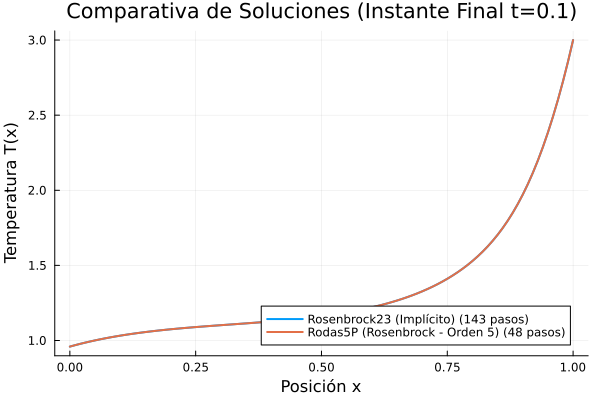

In [1]:
# ==========================================
# PREPARACIÓN DEL ENTORNO
# ==========================================

using Pkg
cd("/home/antonibancells/Desktop/Codi/TFM/ProvesEDOs")
Pkg.activate(".")
using Plots
using LinearAlgebra
using DifferentialEquations, OrdinaryDiffEq

function simular_transitorio_sciml()
    # =================================================================
    # PARÁMETROS GEOMÉTRICOS, FRONTERAS Y PARAMETRIZACIÓN NO LINEAL
    # =================================================================
    L, β, γ, δ = 1.0, 1.5, 0.5, 3.0
    F0, μ = 10.0, 1.0
    
    # Parámetro alfa (factor de escala temporal)
    alpha = 2.0  
    
    σ2_min, σ2_max = 2.0^2, 6.0^2  
    Tc, k_sig = 1.6, 5.0     
    calcular_σ2(T) = σ2_min + (σ2_max - σ2_min) / (1.0 + exp(-k_sig * (T - Tc)))

    N = 100
    dx = L / N
    x_nodos = collect(0:dx:L)
    f(x) = F0 * exp(-μ * x)

    t_final = 0.1
    tspan = (0.0, t_final)

    # Condición inicial: rampa compatible
    T_inicial = [ (i-1)*dx * (δ/L) for i in 1:N ]

    # =================================================================
    # DEFINICIÓN DEL SISTEMA DINÁMICO dT/dt = alpha * G(T, p, t)
    # =================================================================
    function sistema_edo_termico!(dT, T, p, t)
        σ2_local = calcular_σ2.(T)
        
        # Nodo i = 1 (Robin) -> Multiplicado por el factor de escala alpha
        dT[1] = alpha * ( -(1/dx^2 + β/dx + σ2_local[1]/2)*T[1] + (1/dx^2)*T[2] - (-f(0)/2 - γ/dx) )

        # Nodos internos (i = 2 hasta N-1) -> Multiplicados por alpha
        for i in 2:N-1
            dT[i] = alpha * ( (1/dx^2)*T[i-1] - (2/dx^2 + σ2_local[i])*T[i] + (1/dx^2)*T[i+1] - (-f((i-1)*dx)) )
        end

        # Nodo i = N (Dirichlet) -> Multiplicado por alpha
        dT[N] = alpha * ( (1/dx^2)*T[N-1] - (2/dx^2 + σ2_local[N])*T[N] - (-f((N-1)*dx) - (1/dx^2) * δ) )
    end

    # Creamos el problema matemático
    prob = ODEProblem(sistema_edo_termico!, T_inicial, tspan)

    # =================================================================
    # BANCO DE PRUEBAS: SELECCIÓN DE MÉTODOS
    # =================================================================
    metodos = [
        ("Tsit5 (Explícito)", Tsit5()),
        ("Rosenbrock23 (Implícito)", Rosenbrock23()),
        ("Rodas5P (Rosenbrock - Orden 5)", Rodas5P()),
        ("AutoTsit5(Rosenbrock23)", AutoTsit5(Rosenbrock23()))
    ]

    println("="^60)
    println("          BANCO DE PRUEBAS PARA EL TFM (BARRA TÉRMICA)      ")
    println("="^60)

    # Guardaremos aquí los resultados para comparar al final
    resultados = []

    for (nombre, algoritmo) in metodos
        println("▶ Evaluando: $nombre...")
        
        # Primera ejecución (Precompilación JIT oculta)
        solve(prob, algoritmo, reltol=1e-6, abstol=1e-6, save_everystep=false)
        
        # Segunda ejecución: Medición real de tiempo y pasos
        t_inicio = time()
        sol = solve(prob, algoritmo, reltol=1e-6, abstol=1e-6)
        t_duracion = time() - t_inicio  # Cambiado nombre de variable local para no machacar t_final
        
        pasos = length(sol.t)
        
        push!(resultados, (nombre, sol, pasos, t_duracion))
        
        println("  └─ Pasos adaptativos: $pasos")
        println("  └─ Tiempo de cómputo: $(round(t_duracion * 1000, digits=2)) ms")
        println("-"^60)
    end

    # =================================================================
    # GRAFICACIÓN COMPARATIVA FINAL
    # =================================================================
    p_comp = plot(grid=true, title="Comparativa de Soluciones (Instante Final t=$t_final)", 
                  xlabel="Posición x", ylabel="Temperatura T(x)", legend=:bottomright)
    
    for (nombre, sol, pasos, t_comp) in resultados
        # Excluimos Tsit5 de la gráfica si da problemas (debido a la rigidez del problema no lineal)
        if !occursin("Tsit5", nombre)
            # Extraemos la solución en el último instante de tiempo t_final
            T_perfil_final = [sol(t_final); δ]
            plot!(p_comp, x_nodos, T_perfil_final, lw=2, label="$nombre ($pasos pasos)")
        end
    end
    
    display(p_comp)
end

simular_transitorio_sciml()

A causa de la rigidez del sistema, es necesario un método implícito de orden elevado, como Rodas5P (Rosenbrock de 5º orden).